# Q-Learning Algorithm


In [1]:
from Environment import SmartAmbulanceEnv
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Video
import copy
import imageio.v2 as imageio


## Q-Learning Agent

In [2]:
class QLearningAgent:
    def __init__(self, env, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):

        self.env           = env
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_actions     = 4

        # ✅ no gymnasium needed
        self.q_table = np.zeros((env.size * env.size, self.n_actions))

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        return int(np.argmax(self.q_table[state]))

    def learn(self, state, action, reward, next_state, done):
        best_next = np.max(self.q_table[next_state])
        target    = reward + (0 if done else self.gamma * best_next)
        self.q_table[state, action] += self.alpha * (target - self.q_table[state, action])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


## Training

In [3]:
def train_q_learning(env, agent, episodes=3000, max_steps=500):
    rewards = []
    print("===== Q-LEARNING TRAINING =====")
    for ep in range(episodes):
        state, _ = env.reset()
        done, total_reward, steps = False, 0, 0

        while not done and steps < max_steps:
            steps += 1
            action = agent.choose_action(state)
            next_state, reward, done, _, _ = env.step(action)
            agent.learn(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

        agent.decay_epsilon()
        rewards.append(total_reward)

        if ep % 100 == 0:
            avg = np.mean(rewards[-50:])
            print(f"Episode {ep+1:4d} | Reward: {total_reward:6.2f} | "
                  f"Avg(50): {avg:6.2f} | Epsilon: {agent.epsilon:.3f}")
    return rewards

env      = SmartAmbulanceEnv(size=20, seed=69)
ql_agent = QLearningAgent(env)
ql_rewards = train_q_learning(env, ql_agent, episodes=3000)


===== Q-LEARNING TRAINING =====
Episode    1 | Reward: -744.00 | Avg(50): -744.00 | Epsilon: 0.995
Episode  101 | Reward: -260.00 | Avg(50): -529.08 | Epsilon: 0.603
Episode  201 | Reward: -257.00 | Avg(50): -242.36 | Epsilon: 0.365
Episode  301 | Reward: -139.00 | Avg(50): -116.10 | Epsilon: 0.221
Episode  401 | Reward: -87.00 | Avg(50): -45.12 | Epsilon: 0.134
Episode  501 | Reward: -19.00 | Avg(50): -11.38 | Epsilon: 0.081
Episode  601 | Reward: -61.00 | Avg(50):  -1.42 | Epsilon: 0.049
Episode  701 | Reward:   3.00 | Avg(50):  21.56 | Epsilon: 0.030
Episode  801 | Reward:  51.00 | Avg(50):  36.44 | Epsilon: 0.018
Episode  901 | Reward:  24.00 | Avg(50):  40.02 | Epsilon: 0.011
Episode 1001 | Reward:  -7.00 | Avg(50):  45.50 | Epsilon: 0.010
Episode 1101 | Reward:  53.00 | Avg(50):  48.52 | Epsilon: 0.010
Episode 1201 | Reward:  63.00 | Avg(50):  53.42 | Epsilon: 0.010
Episode 1301 | Reward:  63.00 | Avg(50):  47.80 | Epsilon: 0.010
Episode 1401 | Reward:  63.00 | Avg(50):  49.88 | 

## Save Q-Table

In [4]:
np.save("q_table.npy", ql_agent.q_table)
print("Q-table saved as q_table.npy")


Q-table saved as q_table.npy


## Evaluation

In [5]:
def evaluate_q_learning(env, agent, episodes=50, max_steps=500):
    rewards, success = [], 0
    for _ in range(episodes):
        state, _ = env.reset()
        done, total, steps = False, 0, 0
        while not done and steps < max_steps:
            steps += 1
            action = int(np.argmax(agent.q_table[state]))
            state, reward, done, _, _ = env.step(action)
            total += reward
        rewards.append(total)
        if total > 0: success += 1
    avg          = np.mean(rewards)
    success_rate = success / episodes * 100
    print("\n===== Q-LEARNING EVALUATION =====")
    print(f"Average Reward : {avg:.2f}")
    print(f"Success Rate   : {success_rate:.1f}%")
    return avg, success_rate, rewards

after_score, after_success, after_rewards = evaluate_q_learning(env, ql_agent)



===== Q-LEARNING EVALUATION =====
Average Reward : 48.10
Success Rate   : 96.0%


## Before vs After (Random vs Q-Learning)

In [6]:
def random_policy(env, episodes=50, max_steps=500):
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        done, total, steps = False, 0, 0
        while not done and steps < max_steps:
            steps += 1
            action = random.randint(0, 3)
            state, reward, done, _, _ = env.step(action)
            total += reward
        rewards.append(total)
    return np.mean(rewards), rewards

before_score, before_rewards = random_policy(env)

print("===== BEFORE VS AFTER =====")
print(f"Before Training (Random) : {before_score:.2f}")
print(f"After Training (Q-Learn) : {after_score:.2f}")


===== BEFORE VS AFTER =====
Before Training (Random) : -742.78
After Training (Q-Learn) : 48.10


## Learning Curve

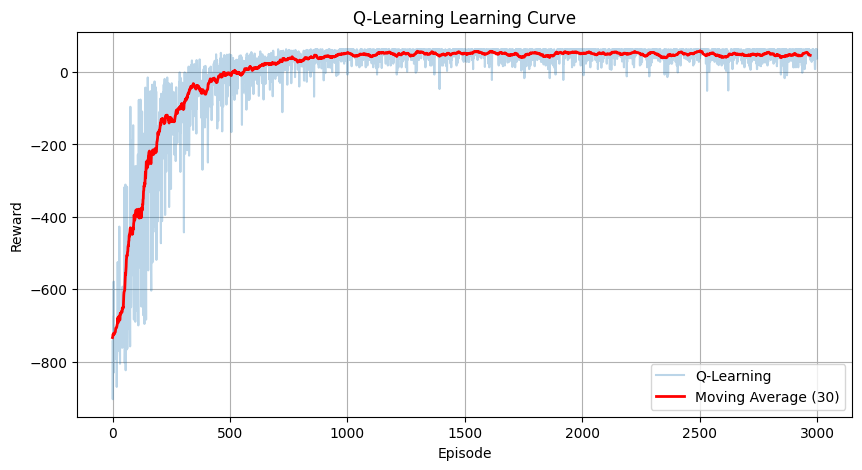

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(ql_rewards, alpha=0.3, label='Q-Learning')
plt.plot(np.convolve(ql_rewards, np.ones(30)/30, mode='valid'),
         'r-', linewidth=2, label='Moving Average (30)')
plt.title('Q-Learning Learning Curve')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid()
plt.savefig('qlearning_learning_curve.png', dpi=120)
plt.show()


## Q-Value Heatmap

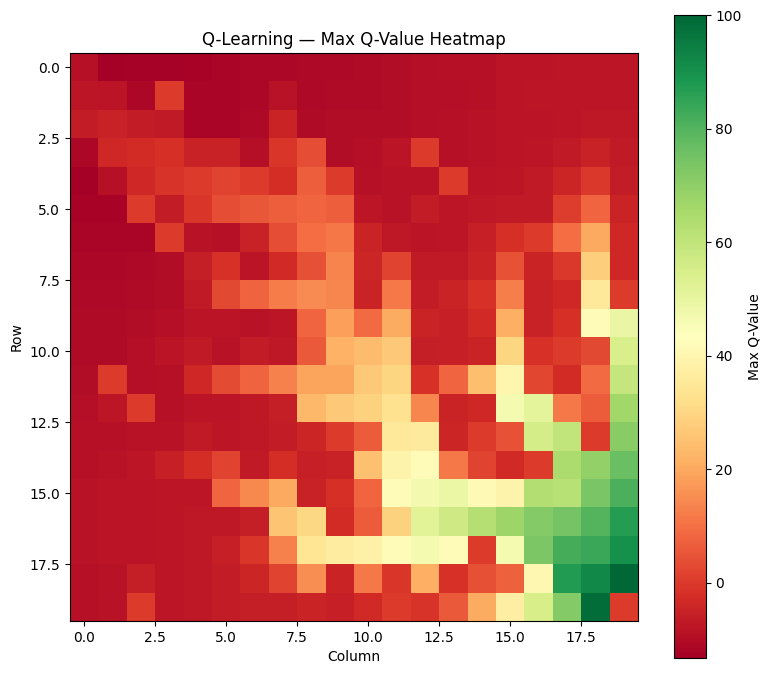

In [8]:
q_max = ql_agent.q_table.max(axis=1).reshape(env.size, env.size)
plt.figure(figsize=(8, 7))
plt.imshow(q_max, cmap='RdYlGn', interpolation='nearest')
plt.colorbar(label='Max Q-Value')
plt.title('Q-Learning — Max Q-Value Heatmap')
plt.xlabel('Column'); plt.ylabel('Row')
plt.tight_layout()
plt.savefig('qlearning_heatmap.png', dpi=120)
plt.show()


## Trajectory Animation

In [11]:
state, _ = env.reset()
done, steps = False, 0
states_history = [state]
lights_history = [copy.deepcopy(env.traffic_lights)]
grid_history   = [env._grid.copy()]

while not done and steps < 200:
    steps += 1
    action = int(np.argmax(ql_agent.q_table[state]))
    state, reward, done, _, _ = env.step(action)
    states_history.append(state)
    lights_history.append(copy.deepcopy(env.traffic_lights))
    grid_history.append(env._grid.copy())

frames = []
for i in range(len(states_history)):
    env._grid = grid_history[i]
    frames.append(env.render_frame(states_history[i], lights_history[i]))

imageio.mimsave("qlearning_video.mp4", frames, fps=8)
print("Saved: qlearning_video.mp4")
Video("qlearning_video.mp4", embed=True)


Saved: qlearning_video.mp4
